# I. Etude du problème d'optimisation

1.  Interpréter la définition de l’énergie auto-consommée. 

Pour calculer l'énergie autoconsommée, on fait la somme sur les différents intervalles de temps. Sur chaque intervalle, on prend le minimum entre l'énergie photovoltaïque produite par les panneaux et la somme  de la consommation non-pilotables et de l'énergie produite par chauffage.

En effet, si on $ E^{PV}_i < w_i + P_i \Delta t $, on prend toute l'énergie produite donc le min. A l'inverse, si  $E^{PV}_i > w_i + P_i \Delta t $, cela signifie que l'on produit plus d'énergie que nécessaire. On va donc seulement consommer $w_i + P_i \Delta t $. 


De manière équivalente, dans la deuxième somme : on choisit le minimum entre l'énergie produite à laquelle on a soustrait l'énergie non-pilotable (on considère le surplus solaire après avoir satisfait les consommations non-pilotables)  et l'énergie pilotable dont on a besoin

La fonction min est convexe mais non différentiable en $P_i \Delta t=E_i P_i$
​, ce qui rend l'optimisation directe difficile (pas de gradient partout). C'est un problème de programmation convexe non lisse.
 


2.  En lieu et place de (4), on se propose de maximiser la fonction dite de "soft-min" $h$ ci-dessous, avec $α > 0$ constante. Justifier que, pour $α$ grand, $h$ est une bonne approximation de la fonction min.
Quel intérêt a-t-on alors à considérer ce problème approché plutôt que le problème original

Soient $x_1, x_2 \in \mathbb{R}$. On a :

$$h(x_1, x_2) = \frac{x_1 e^{-\alpha x_1} + x_2 e^{-\alpha x_2}}{e^{-\alpha x_1} + e^{-\alpha x_2}}$$

Sans perte de généralité, supposons $x_1 \leq x_2$, de sorte que $\min(x_1, x_2) = x_1$.


On factorise par $e^{-\alpha x_1}$ au numérateur et au dénominateur :

$$h(x_1, x_2) = \frac{e^{-\alpha x_1}\left(x_1 + x_2\, e^{-\alpha(x_2 - x_1)}\right)}{e^{-\alpha x_1}\left(1 + e^{-\alpha(x_2 - x_1)}\right)} = \frac{x_1 + x_2\, e^{-\alpha(x_2 - x_1)}}{1 + e^{-\alpha(x_2 - x_1)}}$$

Posons $\delta = x_2 - x_1 \geq 0$, ce qui donne :

$$h(x_1, x_2) = \frac{x_1 + x_2\, e^{-\alpha \delta}}{1 + e^{-\alpha \delta}}$$


**Cas 1 :** $\delta > 0$ (i.e. $x_1 < x_2$). Alors $e^{-\alpha \delta} \to 0$, donc :

$$h(x_1, x_2) \;\longrightarrow\; \frac{x_1 + 0}{1 + 0} = x_1 = \min(x_1, x_2)$$

**Cas 2 :** $\delta = 0$ (i.e. $x_1 = x_2$). Alors :

$$h(x_1, x_2) = \frac{x_1 + x_1}{1 + 1} = x_1 = \min(x_1, x_2)$$

Dans les deux cas :

$$\boxed{h(x_1, x_2) \;\xrightarrow[\alpha \to +\infty]{}\; \min(x_1, x_2)}$$


Pour $\delta > 0$ fixé, l'erreur d'approximation vaut :

$$h(x_1, x_2) - \min(x_1, x_2) = \frac{x_1 + x_2\,e^{-\alpha\delta}}{1 + e^{-\alpha\delta}} - x_1 = \frac{\delta\, e^{-\alpha\delta}}{1 + e^{-\alpha\delta}}$$

Cette quantité est **positive** et tend vers $0$ **exponentiellement vite** quand $\alpha \to +\infty$.




$h$ est une fonction $C^\infty$  pour $\alpha > 0$, ce qui permet d'utiliser des algorithmes de gradient (descente de gradient, L-BFGS, etc.): on peut donc appliquer les résultats d'optmisation vus en cours. 

3. Interpréter l’équation (1). Cette modélisation vous semble-t-elle raisonnable ?

L'équation (1) est une discrétisation du problème. 

La température à l'instant $t+1$ est égale à la température à l'instant $t$ multipliée par la perte de chaleur (vérif nom) à laquelle on ajoute la puissance produite et on soustrait la puissance utilisée pour un éventuel soutirage d'eau, le tout multiplié par un coefficient relatif à la vitesse de refroidissement de l'eau.

VERIFIER. 

4. Formuler le problème d’optimisation à résoudre sous la forme

On veut maximiser l'auto consommation ie on veut maximiser l'énergie PV auto-consommée. Donc, on veut minorer son opposé. On cherche donc $min -f$ (à écrire en latex). 

Ainsi, 
$$ f(x)= 
\sum_{i=1}^{N} h(E_i^{PV}, P_i \Delta t)
= \sum_{i=1}^{N} \frac{x_1 e^{-\alpha x_1} + x_2 e^{-\alpha x_2}}{e^{-\alpha x_1} + e^{-\alpha x_2}}$$

avec $x = (x_1, x_2) = (E^{PV}_i, P_i \Delta t)$. il y a donc $N$ couples de décision (soit $n = 2N$ variables), du fait de la discrétisation. 

Les conditions sont les suivantes : 

**Contraintes d'égalité** $c_{eq}$ :

$$T_{i+1} - e^{-\Delta t/C}T_i - \frac{(1-e^{-\Delta t/C})}{k}(C Q_i + P_i) = 0, \quad i = 0, \ldots, N-1$$

**Contraintes d'inégalité** $c_{in}$ :

$$-P_i \leq 0$$

$$P_i - P_M \leq 0$$

$$-T_i + T_{min} \leq 0$$

$$T_i - T_{set} \leq 0$$




# II. Etude et résolution numérique du problème soft-min 

5. Quelles méthodes de résolution peuvent être envisagées pour ce problème?

D'après le cours, les méthodes envisagées sous ces contraintes sont de suivre les conditions de KKT.   VERIFF 5SCYPY ??

6. Développer un algorithme de résolution dans le cas de l’horizon de temps t0 = 6h et tf = 19h avec
∆t = 0.25h), dans un cas sans usage non-pilotables (wi = 0 pour tout i). On prendra les valeurs
numériques suivantes :
$α =100, k=0.2h−1, Tsat =Tf =70◦C, Tin =50◦
C =100C/Wh, PM =3kW, EPV_i=2e−(ti−13)2/9 $ et $ Q_i = 3W$ pour $t_i = 12 et 0$ sinon.


On tracera notamment les graphes suivants :

(a) l’évolution temporelle de la température du ballon, que l’on superposera aux bornes sur la température

(b) l’évolution temporelle de la puissance fournie au ballon, de la courbe d’énergie photovoltaïque
produite et de l’énergie photovoltaïque auto-consommée correspondante au cours du temps
Commenter les résultats obtenus

Optimization terminated successfully    (Exit mode 0)
            Current function value: -4.738885185322577e-17
            Iterations: 1
            Function evaluations: 62
            Gradient evaluations: 1


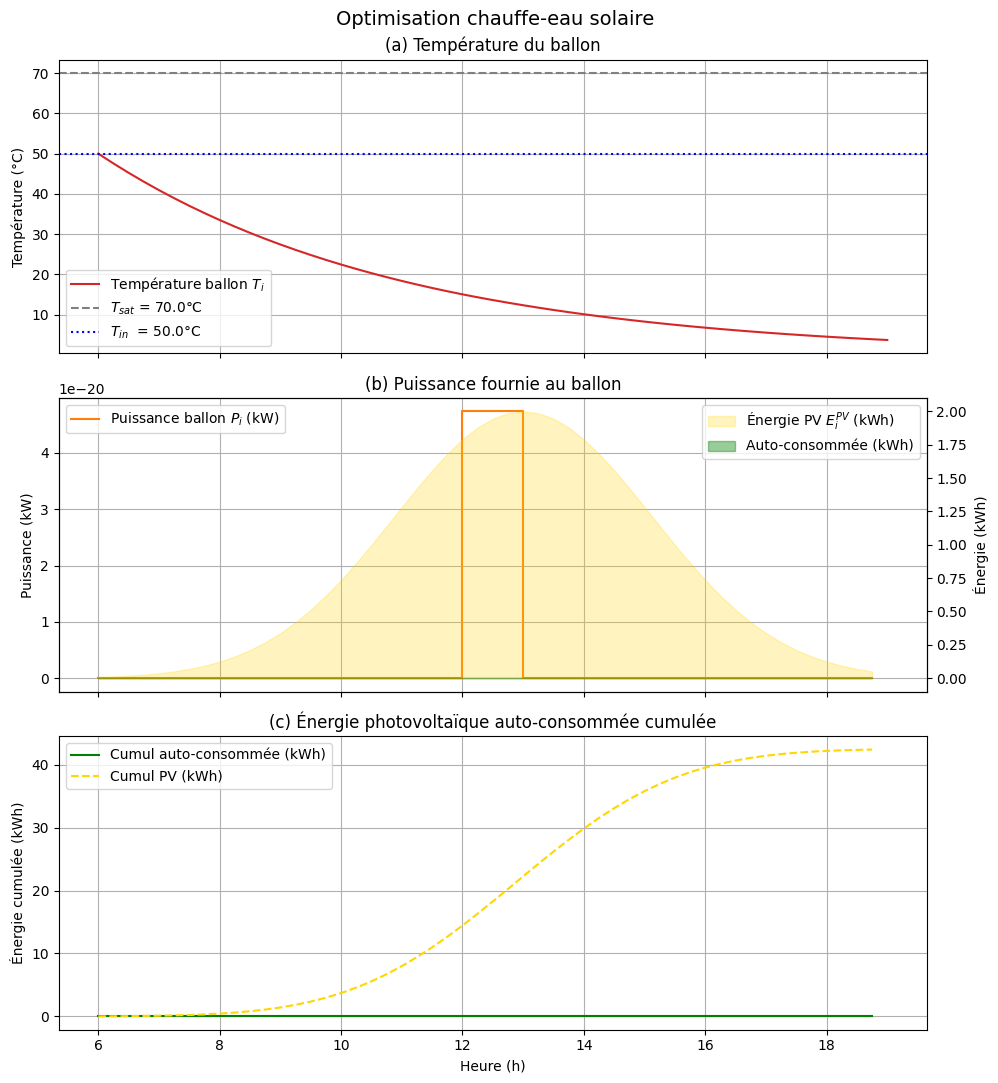


Énergie auto-consommée totale : 0.000 kWh
Énergie PV totale            : 42.404 kWh
Taux d'auto-consommation     : 0.0 %
T finale du ballon           : 3.72 °C


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

alpha_soft = 100
k          = 0.2          # h^{-1}
T_sat      = 70.0         # °C
T_f        = 70.0         # °C  (= T_sat ici)
T_in       = 50.0         # °C
C          = 100.0        # C/Wh
P_M        = 3000.0       # W
E0         = 2.0          # amplitude PV  (kWh → on travaille en Wh ci-dessous)
Q_base     = 3.0          # W  (soutif constant)
T_min_sec  = 0.0          # borne basse température (sécurité)

dt   = 0.25               # h
t0   = 6.0                # h
tf   = 19.0               # h
times = np.arange(t0, tf, dt)   
N    = len(times)

E_PV = 2e3 * np.exp(-(times - 13)**2 / 9)  
Q = np.where((times >= 12) & (times < 13), Q_base, 0.0)   #

# Pas de consommation non-pilotable 
w = np.zeros(N) 

#  Coefficient dynamique 
lam = np.exp(-k * dt)   # e^{-k Δt}

#  Soft-min 
def soft_min(a, b, alpha=alpha_soft):
    ea = np.exp(-alpha * a)
    eb = np.exp(-alpha * b)
    return (a * ea + b * eb) / (ea + eb)

#  Simulation température 
def simulate_T(P):
    T = np.zeros(N + 1)
    T[0] = T_in
    for i in range(N):
        T[i+1] = lam * T[i] + (1 - lam) / k * (Q[i] + P[i]) / C
    return T

#  Objectif : 
def objective(P):
    E_hat = E_PV - w              # surplus PV disponible (Wh)
    P_energy = P * dt             # énergie de chauffe (Wh)
    return -np.sum(soft_min(E_hat, P_energy))

#  Contraintes 
constraints = []

# Dynamique : T_{i+1} = lam*T_i + (1-lam)/k * (Q_i + P_i)/C
def eq_dynamics(P):
    T = simulate_T(P)
    residuals = np.zeros(N)
    for i in range(N):
        residuals[i] = T[i+1] - lam * T[i] - (1 - lam) / k * (Q[i] + P[i]) / C
    return residuals

constraints.append({'type': 'eq', 'fun': eq_dynamics})

# Température dans [T_min_sec, T_sat]
def ineq_T_upper(P):
    T = simulate_T(P)
    return T_sat - T[1:]   # ≥ 0

def ineq_T_lower(P):
    T = simulate_T(P)
    return T[1:] - T_min_sec   # ≥ 0

constraints.append({'type': 'ineq', 'fun': ineq_T_upper})
constraints.append({'type': 'ineq', 'fun': ineq_T_lower})

# Bornes sur P
bounds = [(0, P_M)] * N

#  Optimisation 
P0 = np.zeros(N)   # initialisation

result = minimize(
    objective,
    P0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9, 'maxiter': 1000, 'disp': True}
)

P_opt = result.x
T_opt = simulate_T(P_opt)

#  Énergie auto-consommée 
E_hat      = E_PV - w
P_energy   = P_opt * dt
autoconso  = np.minimum(E_hat, P_energy)   # vraie valeur (pas soft)

#  Graphiques 
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
fig.suptitle("Optimisation chauffe-eau solaire", fontsize=14)

# (a) Température du ballon
ax = axes[0]
ax.plot(np.append(times, tf), T_opt, color='tab:red', label='Température ballon $T_i$')
ax.axhline(T_sat, color='gray', linestyle='--', label=f'$T_{{sat}}$ = {T_sat}°C')
ax.axhline(T_in,  color='blue', linestyle=':',  label=f'$T_{{in}}$  = {T_in}°C')
ax.set_ylabel('Température (°C)')
ax.set_title('(a) Température du ballon')
ax.legend()
ax.grid(True)

# (b) Puissance + énergie PV + énergie auto-consommée
ax = axes[1]
ax.step(times, P_opt / 1000, where='post', color='tab:orange', label='Puissance ballon $P_i$ (kW)')
ax.set_ylabel('Puissance (kW)')
ax.set_title('(b) Puissance fournie au ballon')
ax.legend(loc='upper left')
ax.grid(True)

ax2 = axes[1].twinx()
ax2.fill_between(times, E_PV / 1000, alpha=0.25, color='gold',   label='Énergie PV $E_i^{PV}$ (kWh)')
ax2.fill_between(times, autoconso / 1000, alpha=0.4, color='green', label='Auto-consommée (kWh)')
ax2.set_ylabel('Énergie (kWh)')
ax2.legend(loc='upper right')

# (c) Cumul énergie auto-consommée
ax = axes[2]
ax.plot(times, np.cumsum(autoconso) / 1000, color='green', label='Cumul auto-consommée (kWh)')
ax.plot(times, np.cumsum(E_PV) / 1000,     color='gold',  linestyle='--', label='Cumul PV (kWh)')
ax.set_xlabel('Heure (h)')
ax.set_ylabel('Énergie cumulée (kWh)')
ax.set_title('(c) Énergie photovoltaïque auto-consommée cumulée')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('ballon_solaire.png', dpi=150)
plt.show()

print(f"\nÉnergie auto-consommée totale : {np.sum(autoconso)/1000:.3f} kWh")
print(f"Énergie PV totale            : {np.sum(E_PV)/1000:.3f} kWh")
print(f"Taux d'auto-consommation     : {100*np.sum(autoconso)/np.sum(E_PV):.1f} %")
print(f"T finale du ballon           : {T_opt[-1]:.2f} °C")

COMMENTER

7. On se propose d’introduire $N +1$ variables additionnelles si, telles que $s_i ≤ E^{PV}_i$,  
$i =0,...,N$. Reformuler le problème d’optimisation à l’aide de ces variables

On cherche toujours à maximimser l'énergie auto-consommée, donc à minimiser l'opposé de la fonction associée. 
On a désormais $3N + 1$ variables, et on remarque que Cela signifie que $s_i$​ est un
minorant de  $ \min E_i^{PV}, P_i \Delta t$. 

En maximisant $\sum s_i$, on force $s_i \to \min\{E_i^{PV}, P_i \Delta t\}$ à l'optimum.

Les conditions restent les mêmes que formulées précédemment. 

8. Etudier la convexité de ce nouveau problème. Appartient-il à une famille particulière de problème
d’optimisation? Quels avantages/inconvénients présente-t-il par rapport à la formulation précédente ? 

Convexité : Le problème est désormais linéaire, donc il est bien convexe (mais il est aussi concave). 

Avantages : tout est linéaire. 

Inconvénient : on a désormais 3N + 1 variables

9. Résoudre ce nouveau problème avec les mêmes paramètres que précédemment. Comparer les solutions obtenues.

# IV. Pilotage d’usages blancs et introduction à l’optimisation entière

10. On suppose dans un premier temps que le cycle de la machine à laver est lancée à un temps $t_i0$ 
fixe
donné. Ecrire le problème d’optimisation correspondant.

Ici, $t_i0$ est fixé. Ainsi, on doit prendre en compte la puissance pour $t_{i0} < t < t_{i0} + T$.
On veut toujours maximiser l'auto consommation, donc minorer son opposé. 

Et, 
$$ f(x)
= \sum_{i=1}^{N} \frac{x_1 e^{-\alpha x_1} + x_2 e^{-\alpha x_2}}{e^{-\alpha x_1} + e^{-\alpha x_2}}$$

avec $x = (x_1, x_2) = (E^{PV}_i, P_i \Delta t)$. 

ou encore 

$$f(x) = - \sum_{i=0}^{N-1} \min \{ E_i^{PV}, w_i + (P_i + P_i^L) \Delta t \}$$


####  Contraintes d'inégalité ($c_{in}$)
Le système est limité par les contraintes physiques de sécurité et de puissance

**Température du ballon** : $T_i - T_{sat} \le 0$ et $-T_i \le 0$ pour $i = 0, \dots, N$
**Puissance du chauffe-eau** : $P_i - P_M \le 0$ et $-P_i \le 0$ pour $i = 0, \dots, N-1$



11. A l’aide de ce sous-problème, proposer une approche combinatoire exhaustive permettant de résoudre
le problème originel. L’implémenter avec les mêmes paramètres que précédemment ainsi que $n_L= 6$
et $P^L =0.25W$. Commenter le résultat obtenu. Etudier l’extensibilité de cette technique de résolution
au cas de plusieurs autres usages pilotables